# Relación 3b Nanoelectrónica Teresa Puyol López 


# 1. Resolver el ejercicio 3.11 del libro de Marc Baldo. Calcular primero la situación T=0K y después T=300K.


Next, we consider a Lorenztian density of states rather than simply a discrete level

$$ g(E)dE=\frac{1}{\pi}\frac{\Gamma}{(E-\varepsilon)^2+(\Gamma /2)^2} dE $$

Where $ \Gamma = \Gamma_S + \Gamma_D$ and $\varepsilon$ is the center of the HOMO. Ignore the LUMO, ie. consider the system from problem 9

<img src="ejercicio3b.png" width="600">



### (a) Numerically compare the current-voltage and conductance-voltage characteristics for a distcrete and broadened HOMO with $q^2/C_{ES}=1eV$

In [161]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [162]:
# Constantes  invariantes

hbarrac = 197.3269 #eV*nm
hbarra = 6.582119569*10**(-16) #eV * s
me = 0.511*10**6 #eV/c^2
K = 8.617333262*10**(-5) #eV/K
q = 1.602176634*10**(-19) #C
q_ev = 1 #eV

# Parámetros

eta = 0.5
EF_0 = -5.0
HOMO = -5.5
Gamma_s = 0.1
Gamma_d = 0.1
Gamma = Gamma_s + Gamma_d
mu_s0 = -5.0
mu_d0 = -5.0

tau_s = hbarra/Gamma_s
tau_d = hbarra/Gamma_d

T = 298
V_max = 4 
 
alfa = 0.05 # Para el potencial
convergencia = 10**(-4) # Diferencia entre Us para que converja
pasos =100
max = 200
N_0 = 2 # Número de electrones del homo

In [163]:
# Definiremos funciones para agilizar el código

def fermi(E, E_F):
    #Añadimos para que no sature, porque estamos dividiendo entre infinito cuando integramos

    return 1/(1 + np.exp((E - E_F)/(K*T)))

def DOS(E, Gamma, epsilon):
    return Gamma / (np.pi * ((E - epsilon)**2 + (Gamma/2)**2))

def N_function(E, Gamma_s, Gamma_d, epsilon, mu_s, mu_d):
    tau_s = hbarra/Gamma_s
    tau_d = hbarra/Gamma_d
    # He generalizado eso para responder a la pregunta 2, pero Gamma_S = Gamma_d = Gamma
    return DOS(E, Gamma, epsilon)*(tau_d*fermi(E, mu_s) + tau_s*fermi(E, mu_d))/(tau_s + tau_d)

def Intensidad(E, Gamma, epsilon, mu_s, mu_d):
    tau_s = hbarra/Gamma_s
    tau_d = hbarra/Gamma_d
    return q*DOS(E, Gamma, epsilon)*(fermi(E, mu_s) - fermi(E, mu_d))/(tau_s + tau_d)


In [164]:
# Ahora definimos los arrays de V, N, U y comenzamos el bucle
# Primero hacemos el broaden, que es utilizando la densidad de estados que nos dan

V = np.linspace(-V_max, V_max, pasos)
N = np.zeros(pasos)
U = np.zeros(pasos) 

for i, v_i in enumerate(V):
    mu_s = mu_s0 + eta*v_i
    mu_d = mu_d0 - (1-eta)*v_i

    U_old = 0.0
    iteracion = 0
    error = 1.0
    
    while error>convergencia and iteracion < max:

        #N_calc, error_N = quad(lambda E: N_function(E, Gamma_s, Gamma_d, HOMO + U_old, mu_s, mu_d), -np.inf, np.inf)

        # La función quad da problemas porque no consigo obtener la función correcta con ella, así que voy a intentar integrar con otra función

        E = np.linspace(HOMO + U_old - 10*Gamma, HOMO + U_old + 10*Gamma, 2000)
        # Lo que le sumo y resto es porque entre esos valores DOS tiene un valor finito
        # El último número es el número de puntos que se toman, es suficiente para la integral que queremos hacer 
        integral = DOS(E, Gamma, HOMO + U_old) * (tau_d*fermi(E, mu_s) + tau_s*fermi(E, mu_d)) / (tau_s + tau_d)
        
        N_calc = np.trapezoid(integral, E)
        U_aux = 1.0*(N_calc - N_0) 
        U_calc = U_old + alfa*(U_aux- U_old)
        error = np.abs(U_calc - U_old)

        # Actualizamos
        U_old = U_calc
        iteracion += 1
    
    U[i] = U_old
    N[i] = N_calc


error_I = np.zeros(pasos)
I = np.zeros(pasos)

for i, vi in enumerate(V):
    mu_s = mu_s0 + eta*vi
    mu_d = mu_d0 - (1-eta)*vi
    #I[i], error_I[i] = quad(lambda E: Intensidad(E, Gamma, HOMO + U[i], mu_s, mu_d), -np.inf, np.inf)
    integral_I = DOS(E, Gamma, HOMO + U[i]) * (fermi(E, mu_s) - fermi(E, mu_d))
    I[i] =( q * np.trapezoid(integral_I, E) / (tau_s + tau_d))*10**6
    
G_broaden = np.gradient(I, V)  
I_broaden = I.copy()



In [165]:
# Ahora calculamos la de no broadening, que es que la densidad de estados sea una delta
# Es el código del ejercicio 1b de antes

U = np.linspace(-V_max, V_max, pasos)

for i, vi in enumerate(V):
    mu_s = mu_s0 + eta*vi
    mu_d = mu_d0 - (1-eta)*vi

    U_old = 0.0
    iteracion = 0
    error = 1.0
    
    while error>convergencia and iteracion < max:
        N_calc = 2.0*(tau_d*fermi(HOMO+U_old, mu_s) + tau_s*fermi(HOMO + U_old, mu_d))/(tau_d + tau_s)
        U_aux = 1.0*(N_calc - N_0) #comprobar si esto hace falta
        U_calc = U_old + alfa*(U_aux- U_old)
        error = np.abs(U_calc - U_old)

        # Actualizamos
        U_old = U_calc
        iteracion += 1
    
    U[i] = U_old
    N[i] = N_calc


for i, vi in enumerate(V):
    mu_s = mu_s0 + eta*vi
    mu_d = mu_d0 - (1-eta)*vi
    I[i] = 2*q*(fermi(HOMO + U[i], mu_s)-fermi(HOMO + U[i], mu_d))/(tau_d+tau_s)*10**6

    
#G = np.gradient(I, V)   

# Se podría hacer la conductancia con la anterior función y ya, pero sale demasiado ruido en los picos de esta
# Así que he encontrado la siguiente funcion que "suaviza" la intensidad para que el gradiente no tenga tanto ruido

from scipy.signal import savgol_filter     

I_suave = savgol_filter(I, 31, 3)   
G_nobroaden = np.maximum(np.gradient(I_suave, V),0)
I_nobroaden = I.copy()


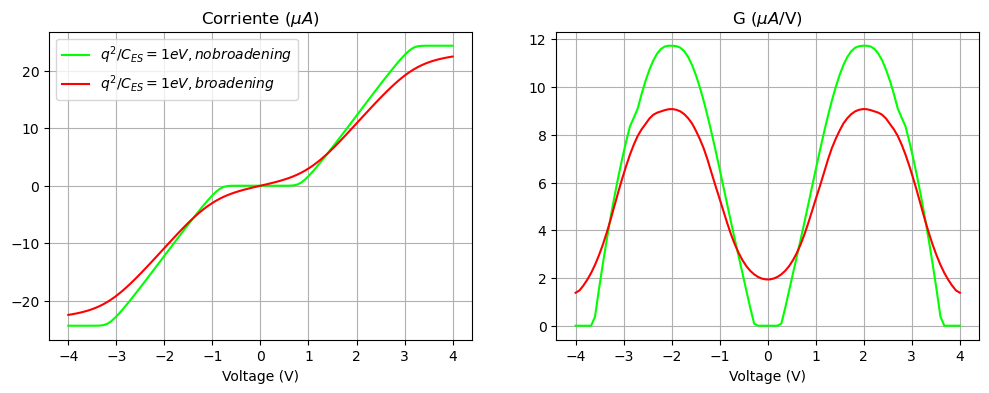

In [166]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(V, I_nobroaden, label=r"$q^2/C_{ES} = 1eV, no broadening $", color = 'lime')
plt.plot(V, I_broaden, label=r"$q^2/C_{ES} = 1eV, broadening $", color = 'red')
plt.title(r"Corriente ($\mu A$)")
plt.xlabel("Voltage (V)")
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(V,G_nobroaden, label=r"$q^2/C_{ES} = 0 $", color = 'lime')
plt.plot(V,G_broaden, label=r"$q^2/C_{ES} = 1 $", color = 'red')
plt.title(r"G ($\mu A$/V)")
plt.xlabel("Voltage (V)")
plt.grid()


Encontramos las mismas curvas que aparecen en el libro de Marc Baldo.

He tenido que cambiar el método de integración, porque si no no salía la curva roja correcta.

### (b) How would you expect the IV to change if $\Gamma_S$ > $\Gamma_D$? Explain.

Si es $\Gamma_S$ > $\Gamma_D$, se incrementa el contacto y disminuye el tiempo con la fuente (y al contrario con el otro borde, con el drenador)

Entonces la curva se ensancha y se acerca más a la fuente.

Como ahora $\Gamma$ tiene un distinto valor para cada zona, la intensidad ahora no es simétrica.

